In [2]:
import numpy as np
import matplotlib.pyplot as plt

from edibles.utils.local_continuum_spline import *
from edibles.utils.final_voigt_profile import *
from edibles.utils.final_fitter import *

from IPython.display import display, Math

from scipy.interpolate import CubicSpline



/Users/ayansahoo/Desktop/MITACS/edibles_spec/DR4
***Common Objects***
['HD 61827']
**Filtered File List**
19631    /HD61827/BLUE_437/HD61827_w437_n6_20180317_B.fits
19634    /HD61827/BLUE_437/HD61827_w437_blue_20180317_O...
19651    /HD61827/BLUE_437/HD61827_w437_blue_20180317_O...
Name: Filename, dtype: object
3
***Common Objects***
['HD 61827']
**Filtered File List**
19631    /HD61827/BLUE_437/HD61827_w437_n6_20180317_B.fits
Name: Filename, dtype: object
1


/var/folders/x3/g_6bp6fj0vx0dk27lr5119r80000gn/T/ipykernel_1354/3532471551.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


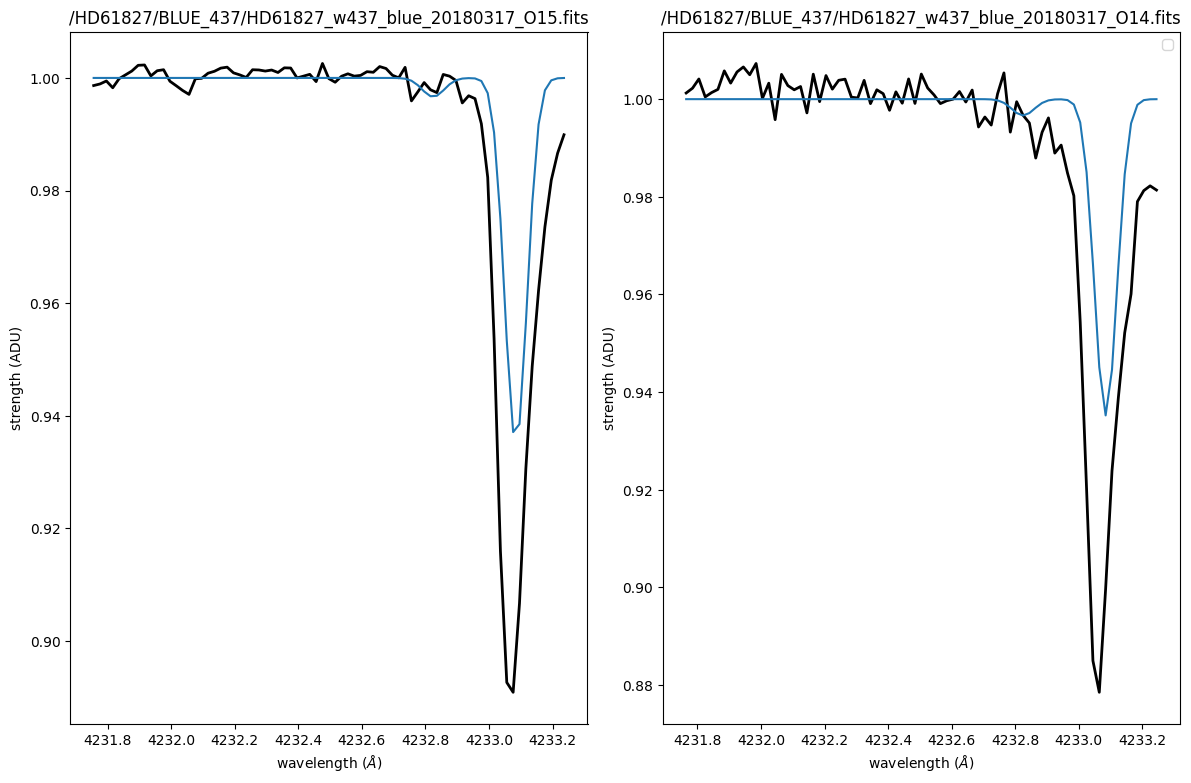

/HD61827/BLUE_437/HD61827_w437_blue_20180317_O15.fits
/HD61827/BLUE_437/HD61827_w437_blue_20180317_O14.fits


In [190]:
sightline = "HD 61827"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=4232.0)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=4232.0)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [4232.288, 4232.548]
f = [0.005450, 0.005450]
gamma = [1e8,1e8]
b = [3, 3]
N = [6.8e12/20, 6.8e12]#[1.3e13/50, 1.3e13]
map = [0, 1]
v_rad = 38
v_resolution = 3
B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [4231.75, 4233.25]
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(wave, flux, color='k', linewidth=2)

    y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
                       b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('wavelength ($\AA$)')
    axs[i].set_ylabel('strength (ADU)')

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)

/var/folders/x3/g_6bp6fj0vx0dk27lr5119r80000gn/T/ipykernel_1354/217443568.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


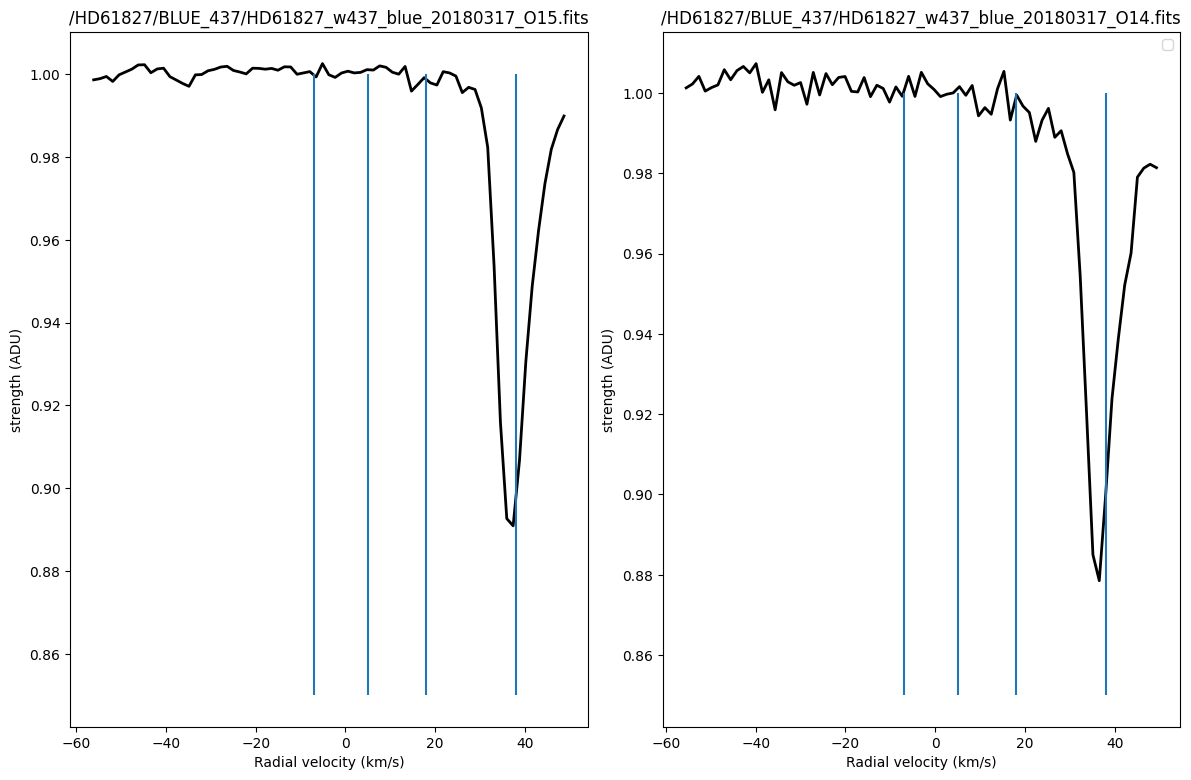

/HD61827/BLUE_437/HD61827_w437_blue_20180317_O15.fits
/HD61827/BLUE_437/HD61827_w437_blue_20180317_O14.fits


In [189]:

lambda_for_vel_prof = [4232.548]
ref_wave = 4232.548
cl_1 = 38
cl_2 = -7
cl_3 = 5
cl_4 = 18
# cl_5 = -26
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [4231.75, 4233.25]
    
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0.85, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0.85, ymax=1)
    axs[i].vlines(x=cl_3, ymin=0.85, ymax=1)
    axs[i].vlines(x=cl_4, ymin=0.85, ymax=1)
    # axs[i].vlines(x=cl_5, ymin=0.8, ymax=1)
    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('Radial velocity (km/s)')
    axs[i].set_ylabel('strength (ADU)')

    # axs[i].set_xlim(-50, 50)

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   

for i in test:
    print(i)


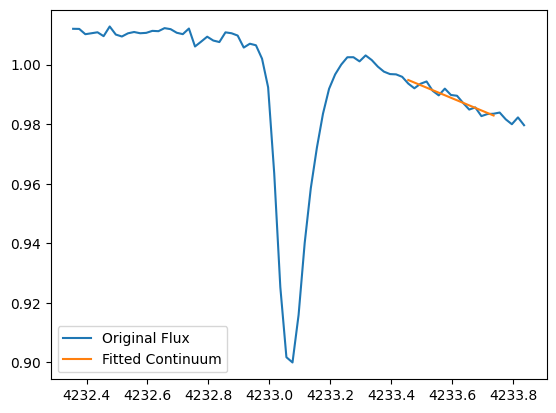

Standard deviation of flux: 0.001282598987749399


In [192]:
filename = test[0] # mention the file which needs fitting
wrange = [4232.35, 4233.85]
sp = EdiblesSpectrum(filename)
sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
wave = sp.bary_wave
flux = sp.bary_flux

# Filter the spectrum within the specified wavelength range
idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
wave = wave[idx]
flux = flux[idx]
# Normalize the flux
flux = flux / np.median(flux)
continuum, std_dev = local_continuum(wave, flux, positions=[4233.6], windows=[0.3], spline_order=1, silent=False)
print("Standard deviation of flux:", std_dev)

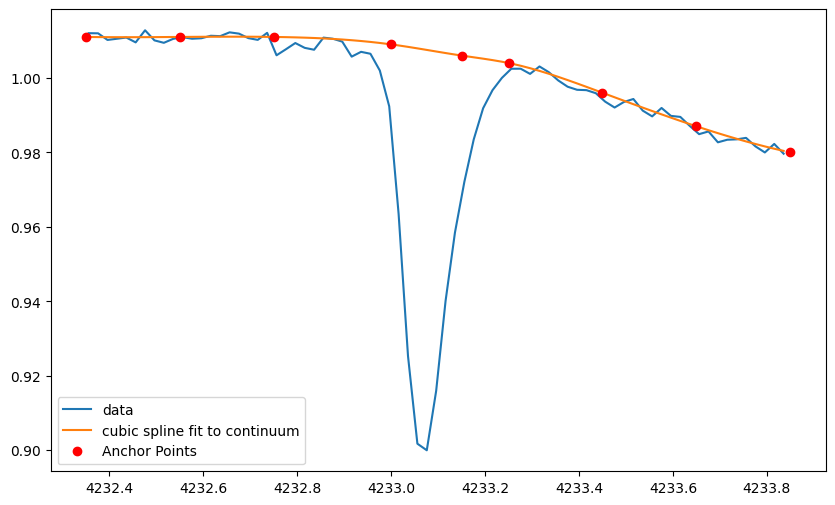

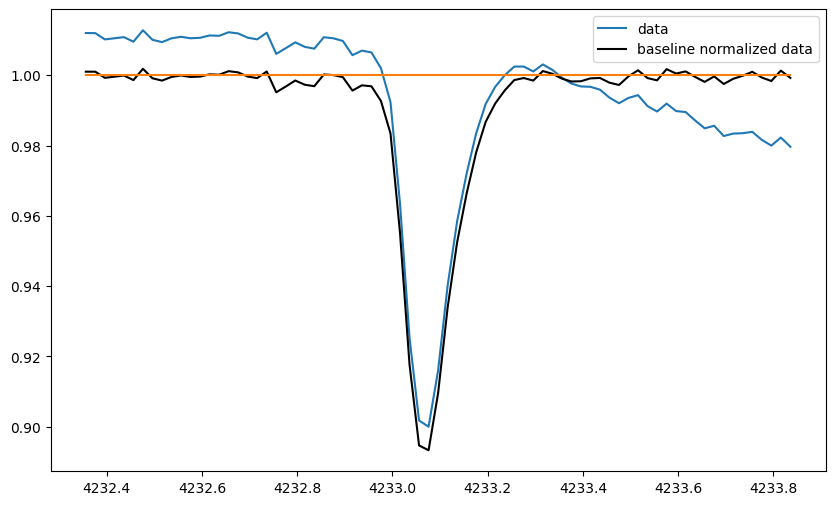

In [211]:

## next try to fit continuum using cubic splines

anchor_points_wave = np.array([4232.35, 4232.55, 4232.75, 4233, 4233.15, 4233.25, 4233.45, 4233.65, 4233.85]) #np.array([4232.25, 4232.5, 4232.75, 4233, 4233.25, 4233.5, 4233.75, 4234])
anchor_points_flux = np.array([1.011, 1.011, 1.011, 1.009, 1.006, 1.004, 0.996, 0.987, 0.98])#np.array([1.001, 1.001, 1.001, 1.001, 1.001, 1.001, 1.001, 1.001, 1.002])
# anchor_points_wave = np.array([4231, 4231.25, 4231.5, 4231.75, 4232, 4232.12, 4232.29, 4232.72, 4232.85, 4233])
# anchor_points_flux = np.interp(anchor_points_wave, wave, flux)

# Fit cubic splines to the anchor points
cs = CubicSpline(anchor_points_wave, anchor_points_flux) # so the cubic spline routine is not really taking all the points into account. only anchors

# Generate the continuum model
continuum = cs(wave)

plt.figure(figsize=(10, 6))
plt.plot(wave, flux, label='data')
plt.plot(wave, continuum, label='cubic spline fit to continuum')
plt.plot(anchor_points_wave, anchor_points_flux, 'ro', label='Anchor Points')
plt.legend()
plt.show()

H = np.ones(wave.shape)
plt.figure(figsize=(10, 6))
plt.plot(wave, flux, label='data')
plt.plot(wave, flux / continuum, color='k', label='baseline normalized data')
plt.plot(wave, H)
plt.legend()
plt.show()

